Load packages, set data paths and variables

In [ ]:
from pathlib import Path
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from db_queries import get_location_metadata
from matplotlib.ticker import MaxNLocator

# Variables ####################################################################
DATA_PATH = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/training_data/2026_09_13.01/data.parquet"
PLOT_OUTPUT = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/"


OUTPUT_PATH = (
    Path(PLOT_OUTPUT) / "covariates_by_country.pdf"
)  # TODO: set final destination
STRATUM_OUTPUT_PATH = Path(PLOT_OUTPUT) / "covariates_by_mortality_status.pdf"
locs = get_location_metadata(location_set_id=39, release_id=16)
countries = ["Namibia", "Angola", "Rwanda"]
vars_of_interest = ["consumption_pd"]  # , "days_over_30C_prev_0_mo"]
VAR_LABELS = {
    "consumption_pd": "Consumption per day",
    "days_over_30C_prev_0_mo": "Days over 30C (previous month)",
}
POINT_COLOR = "#9dc0d8"
BOX_COLOR = "#1f4257"
STATUS_COLORS = {0: "#9dc0d8", 1: "#d1495b"}

In [3]:
# Load data
df = pd.read_parquet(DATA_PATH)

In [4]:
sorted([c for c in df.columns])

['age_group_id',
 'age_month',
 'age_month_original',
 'any_days_over_30C',
 'aod_months',
 'birth_month',
 'birth_year',
 'child_alive',
 'child_mortality',
 'consumption',
 'consumption_pd',
 'cum_weight',
 'days_over_24C_prev_0_mo',
 'days_over_24C_prev_1_mo',
 'days_over_24C_prev_2_mo',
 'days_over_24C_prev_3_mo',
 'days_over_24C_prev_3_mo_avg',
 'days_over_24C_prev_4_mo',
 'days_over_24C_prev_5_mo',
 'days_over_24C_prev_6_mo',
 'days_over_24C_prev_6_mo_avg',
 'days_over_24C_prev_7_mo',
 'days_over_24C_prev_8_mo',
 'days_over_24C_prev_9_mo',
 'days_over_24C_prev_9_mo_avg',
 'days_over_25C_prev_0_mo',
 'days_over_25C_prev_1_mo',
 'days_over_25C_prev_2_mo',
 'days_over_25C_prev_3_mo',
 'days_over_25C_prev_3_mo_avg',
 'days_over_25C_prev_4_mo',
 'days_over_25C_prev_5_mo',
 'days_over_25C_prev_6_mo',
 'days_over_25C_prev_6_mo_avg',
 'days_over_25C_prev_7_mo',
 'days_over_25C_prev_8_mo',
 'days_over_25C_prev_9_mo',
 'days_over_25C_prev_9_mo_avg',
 'days_over_26C_prev_0_mo',
 'days_over_

In [5]:
# Format data
df = df.merge(locs[["ihme_loc_id", "location_name"]], on="ihme_loc_id", how="left")

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/covariates_by_country.pdf


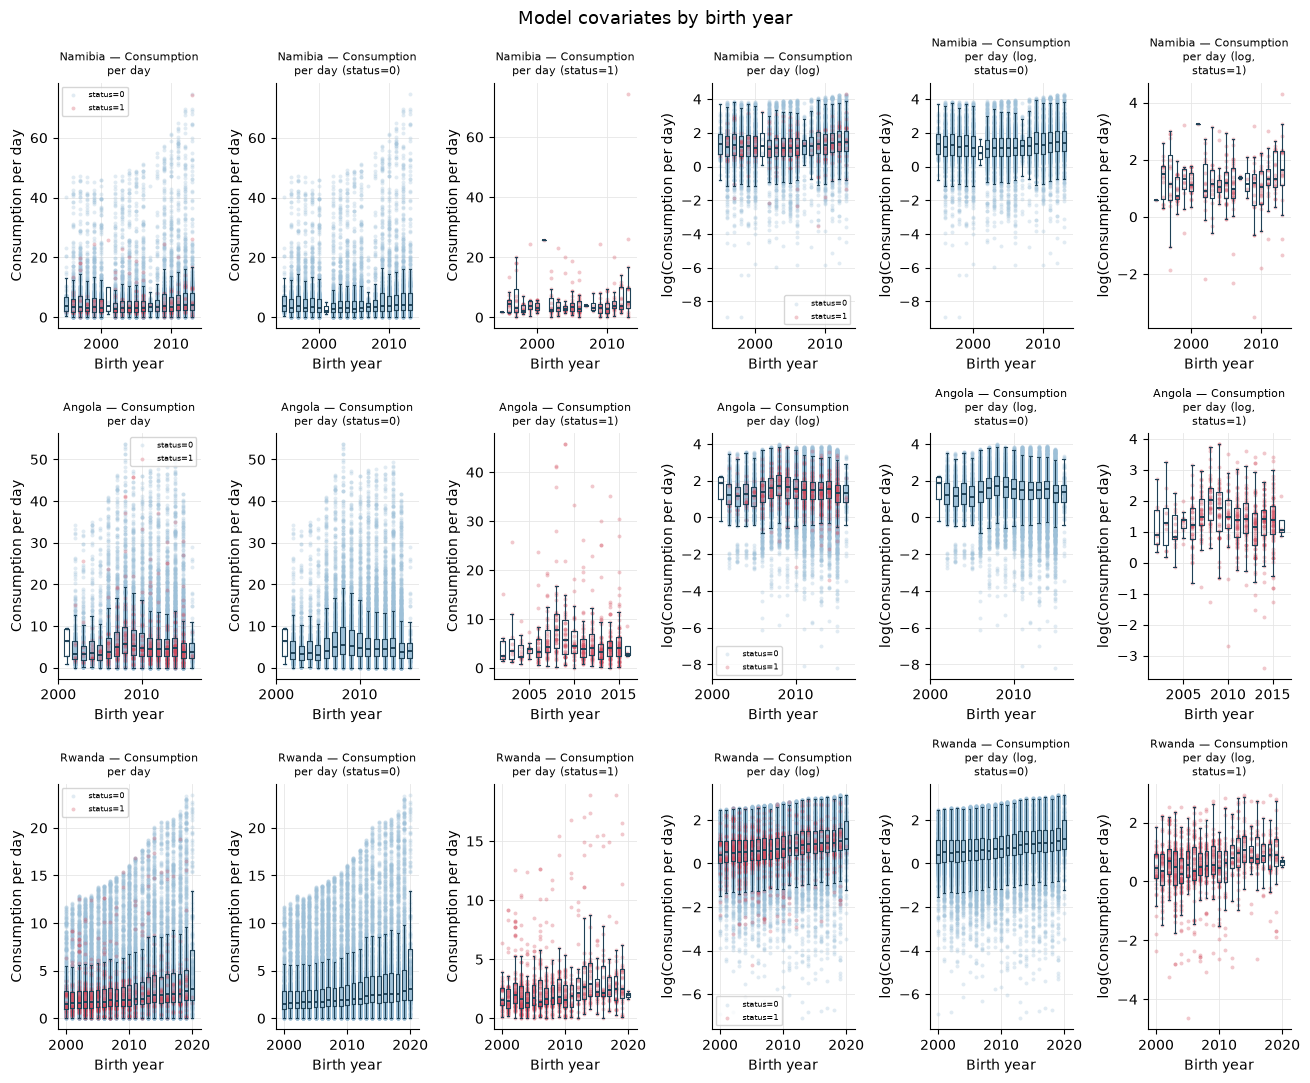

In [6]:
# Plot variables of interest ###################################################
# Small multiples: one row per country. For each variable of interest there are
# six columns: (1) all data color-coded by status with a per-birth-year box plot
# overlay, (2) status=0 only, (3) status=1 only, (4) all data in log-space
# color-coded by status, (5) status=0 in log-space, (6) status=1 in log-space.
# Every column also gets its own per-birth-year box plot overlay.
import textwrap

STATUS_COL = "neonatal_mortality"
N_STATUS_COLS = 6
TITLE_WRAP_WIDTH = 22
ncols = N_STATUS_COLS * len(vars_of_interest)

fig, axes = plt.subplots(
    nrows=len(countries),
    ncols=ncols,
    figsize=(2.2 * ncols, 11),
)
axes = np.atleast_2d(axes)


def _wrapped_title(ax, title):
    ax.set_title(textwrap.fill(title, TITLE_WRAP_WIDTH), fontsize=8)


def _scatter_by_status(ax, data, x_col, y):
    for status, color in STATUS_COLORS.items():
        mask = data[STATUS_COL] == status
        ax.scatter(
            data.loc[mask, x_col],
            y[mask],
            color=color,
            s=8,
            alpha=0.3,
            linewidths=0,
            zorder=1,
            label=f"status={status}",
        )


def _boxplot_overlay(ax, x, y):
    grouped = y.dropna().groupby(x)
    positions = [year for year, _ in grouped]
    distributions = [values.to_numpy() for _, values in grouped]
    if distributions:
        ax.boxplot(
            distributions,
            positions=positions,
            widths=0.6,
            manage_ticks=False,
            showfliers=False,
            zorder=2,
            boxprops={"color": BOX_COLOR, "linewidth": 0.8},
            whiskerprops={"color": BOX_COLOR, "linewidth": 0.8},
            capprops={"color": BOX_COLOR, "linewidth": 0.8},
            medianprops={"color": BOX_COLOR, "linewidth": 1.4},
        )


for row, country in enumerate(countries):
    subset = df[df["location_name"] == country]
    for vidx, var in enumerate(vars_of_interest):
        base_col = N_STATUS_COLS * vidx
        var_label = VAR_LABELS.get(var, var)

        # Column 1: all data color-coded by status, with a box plot overlay.
        ax = axes[row, base_col]
        _scatter_by_status(ax, subset, "birth_year", subset[var])
        _boxplot_overlay(ax, subset["birth_year"], subset[var])
        _wrapped_title(ax, f"{country} — {var_label}")
        ax.set_ylabel(var_label)
        ax.legend(fontsize=6, loc="best")

        # Column 4: all data in log-space, color-coded by status.
        ax = axes[row, base_col + 3]
        log_y = np.log(subset[var].where(subset[var] > 0))
        _scatter_by_status(ax, subset, "birth_year", log_y)
        _boxplot_overlay(ax, subset["birth_year"], log_y)
        _wrapped_title(ax, f"{country} — {var_label} (log)")
        ax.set_ylabel(f"log({var_label})")
        ax.legend(fontsize=6, loc="best")

        # Columns 2, 3, 5, 6: scatters split by status, raw and log-space.
        panel_specs = [
            (1, 0, False, f"{country} — {var_label} (status=0)"),
            (2, 1, False, f"{country} — {var_label} (status=1)"),
            (4, 0, True, f"{country} — {var_label} (log, status=0)"),
            (5, 1, True, f"{country} — {var_label} (log, status=1)"),
        ]
        for col_offset, status, log_space, title in panel_specs:
            ax = axes[row, base_col + col_offset]
            status_subset = subset[subset[STATUS_COL] == status]
            y = status_subset[var]
            ylabel = var_label
            if log_space:
                y = np.log(y.where(y > 0))
                ylabel = f"log({var_label})"
            ax.scatter(
                status_subset["birth_year"],
                y,
                color=STATUS_COLORS[status],
                s=8,
                alpha=0.3,
                linewidths=0,
                zorder=1,
            )
            _boxplot_overlay(ax, status_subset["birth_year"], y)
            _wrapped_title(ax, title)
            ax.set_ylabel(ylabel)

for ax in axes.flat:
    ax.grid(True, color="0.9", linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_xlabel("Birth year")

fig.suptitle("Model covariates by birth year", fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_PATH, format="pdf", bbox_inches="tight")
print(f"Saved {OUTPUT_PATH}")
plt.show()

Make aggregated version of dataset at country level

In [7]:
# Aggregate to country level ###################################################
df["log_consumption_pd"] = np.log(df["consumption_pd"].where(df["consumption_pd"] > 0))

df_agg = (
    df.groupby(["ihme_loc_id", "sex_id", "birth_year"])
    .agg(
        consumption_pd=("consumption_pd", "mean"),
        log_consumption_pd=("log_consumption_pd", "mean"),
        neonatal_mortality=("neonatal_mortality", "mean"),
    )
    .reset_index()
)
df_agg

,ihme_loc_id,sex_id,birth_year,consumption_pd,log_consumption_pd,neonatal_mortality
0,AGO,1,2001,6.171319,1.706684,0.000000
1,AGO,1,2002,5.334630,1.222687,0.025000
2,AGO,1,2003,4.429740,1.110586,0.029630
3,AGO,1,2004,5.921339,1.288257,0.036364
4,AGO,1,2005,4.426929,1.055021,0.017668
...,...,...,...,...,...,...
1830,ZWE,2,2011,5.692861,1.376880,0.022436
1831,ZWE,2,2012,5.568735,1.371317,0.032590
1832,ZWE,2,2013,6.233353,1.454715,0.018116
1833,ZWE,2,2014,6.194185,1.427455,0.020690


In [10]:
df_agg["birth_year"].dtype

dtype('int64')

In [8]:
df_agg = df_agg.merge(
    locs[["ihme_loc_id", "location_name"]], on="ihme_loc_id", how="left"
)

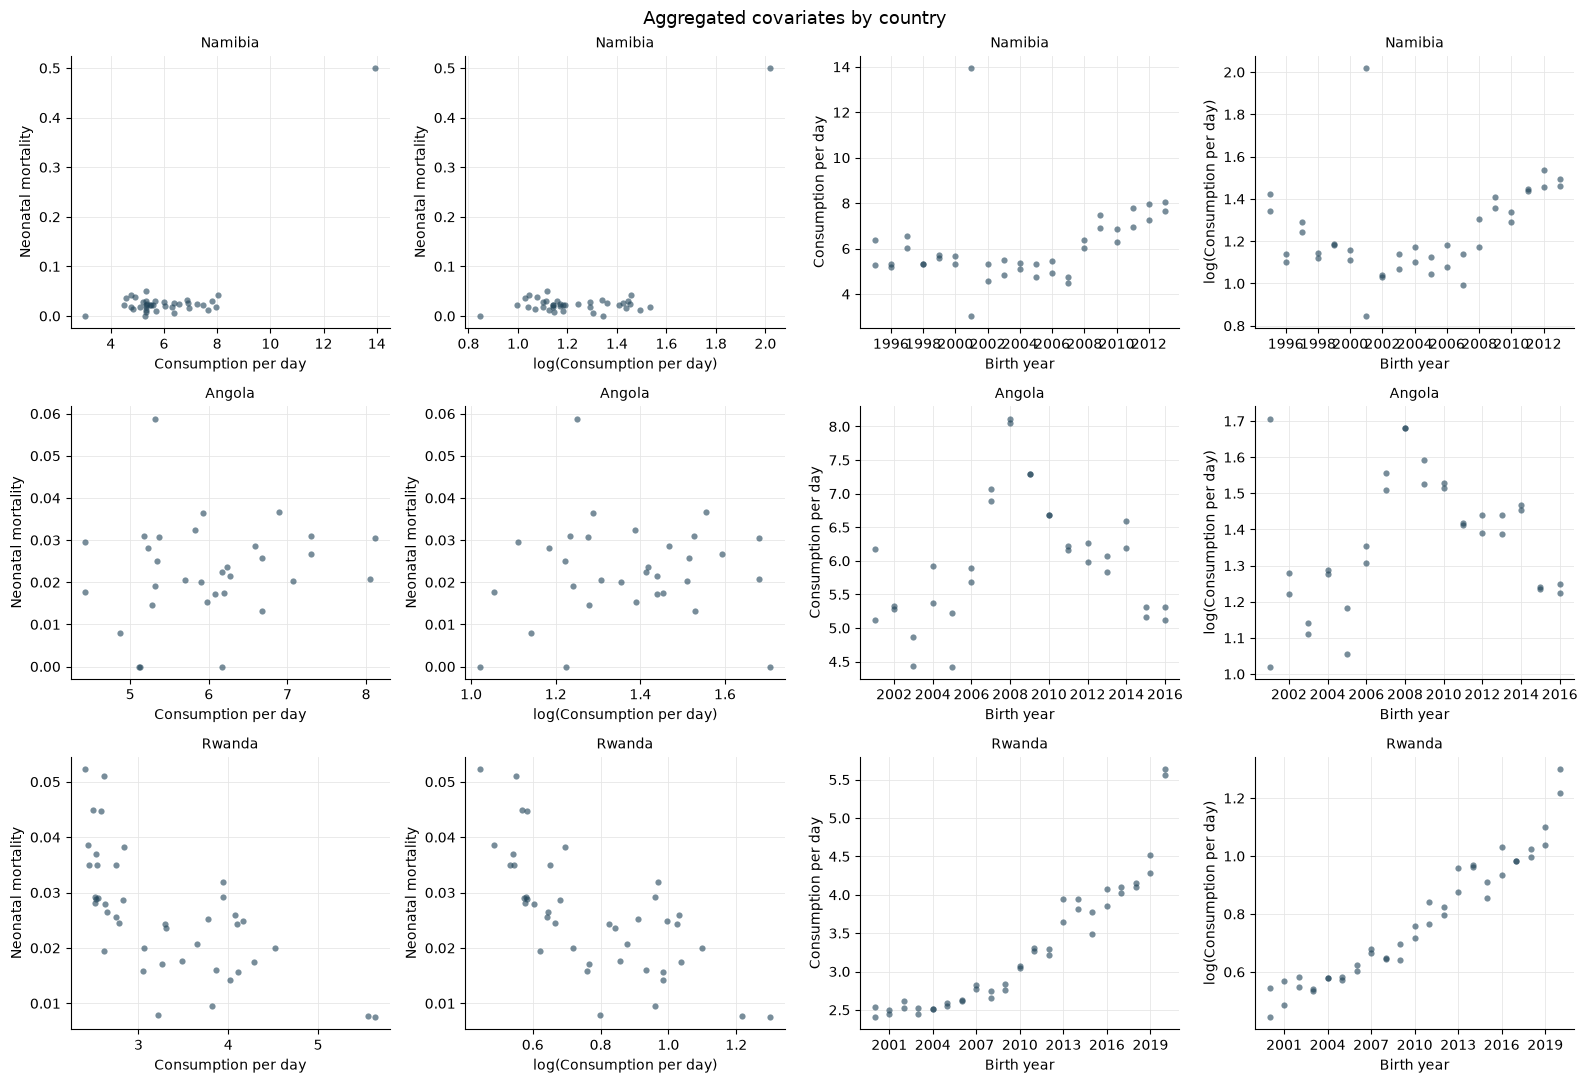

In [ ]:
# Plot aggregated relationships #################################################
# One row per country, four columns: neonatal mortality vs. consumption_pd,
# neonatal mortality vs. log_consumption_pd, consumption_pd vs. birth_year, and
# log_consumption_pd vs. birth_year.
agg_panel_specs = [
    (
        "consumption_pd",
        "neonatal_mortality",
        "Consumption per day",
        "Neonatal mortality",
    ),
    (
        "log_consumption_pd",
        "neonatal_mortality",
        "log(Consumption per day)",
        "Neonatal mortality",
    ),
    ("birth_year", "consumption_pd", "Birth year", "Consumption per day"),
    ("birth_year", "log_consumption_pd", "Birth year", "log(Consumption per day)"),
]


fig, axes = plt.subplots(
    nrows=len(countries),
    ncols=len(agg_panel_specs),
    figsize=(4 * len(agg_panel_specs), 11),
)
axes = np.atleast_2d(axes)

for row, country in enumerate(countries):
    subset = df_agg[df_agg["location_name"] == country]
    for col, (x_col, y_col, x_label, y_label) in enumerate(agg_panel_specs):
        ax = axes[row, col]
        ax.scatter(
            subset[x_col],
            subset[y_col],
            color=BOX_COLOR,
            s=20,
            alpha=0.6,
            linewidths=0,
            zorder=1,
        )
        ax.set_title(f"{country}", fontsize=10)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.grid(True, color="0.9", linewidth=0.6)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        if x_col == "birth_year":
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))

fig.suptitle("Aggregated covariates by country", fontsize=13)
fig.tight_layout()
plt.show()